# Nestedness figures

Fig. 2a and Supplementary Fig. S3a, S3b, drawn from the saved discovery-matrix summaries of this stage. Each panel is written to `figures/` (PDF) and, except S3b, the values it plots to `data/` (CSV).

The notebook reads the frozen paper results (`results_reference/`) by default. To plot a rerun, run `bash 1_preprocessing/run.sh`, `bash 2_global_trend/run.sh` and `bash 5_response_hierarchy/run.sh`, then set `USE_REFERENCE=0` (or `USE_REFERENCE = False` below) to read `results/`.

In [1]:
%matplotlib inline
import os
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

sys.path.insert(0, "..")  # the repository root, for utils
from utils.paths import REPO_ROOT, RESIDUAL_DISCOVERIES, RESIDUAL_DISCOVERIES_CANONICAL, paper_name, reference
from utils.plotting import MM, PAPER_ORDER, panel_style, save_panel, use_style

USE_REFERENCE = os.environ.get("USE_REFERENCE", "1") != "0"


def results_dir(path):
    return reference(path) if USE_REFERENCE else path


RESIDUAL = results_dir(RESIDUAL_DISCOVERIES)
NESTEDNESS = results_dir(RESIDUAL_DISCOVERIES_CANONICAL)
TRIANGLES = NESTEDNESS / "triangle_visualization_polish"
CAPTURE = NESTEDNESS / "capture_curve_comparison"

FIGURES = REPO_ROOT / "5_response_hierarchy" / "figures"
DATA = REPO_ROOT / "5_response_hierarchy" / "data"
FIGURES.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)


def triangle_matrix(frame, dataset, value_column):
    """20 x 20 triangle of one dataset: held-out perturbation bins down, training gene bins across."""
    part = frame.loc[frame["display_dataset"] == dataset]
    return (
        part.pivot(index="row_bin", columns="gene_bin", values=value_column)
        .sort_index(axis=0)
        .sort_index(axis=1)
        .to_numpy(dtype=float)
    )


def draw_triangle(axis, frame, dataset, value_column, norm):
    """One triangle in reds (Fig. 2a, S3b)."""
    return axis.imshow(
        triangle_matrix(frame, dataset, value_column), cmap="Reds", norm=norm, interpolation="nearest",
        aspect="equal", origin="upper",
    )

## Fig. 2a — held-out rejection triangles and matched capture curves

VCC-H1 and Nadig-HepG2 Total/Residual triangles (`triangle_visualization_polish/` of `RESIDUAL_DISCOVERIES_CANONICAL`) and the capture curves of 10 datasets (`capture_curve_comparison/`), from `5_response_hierarchy/compute_matched_nestedness.py --mode aggregate`: equal-dataset means with pointwise 10th–90th percentile ribbons.

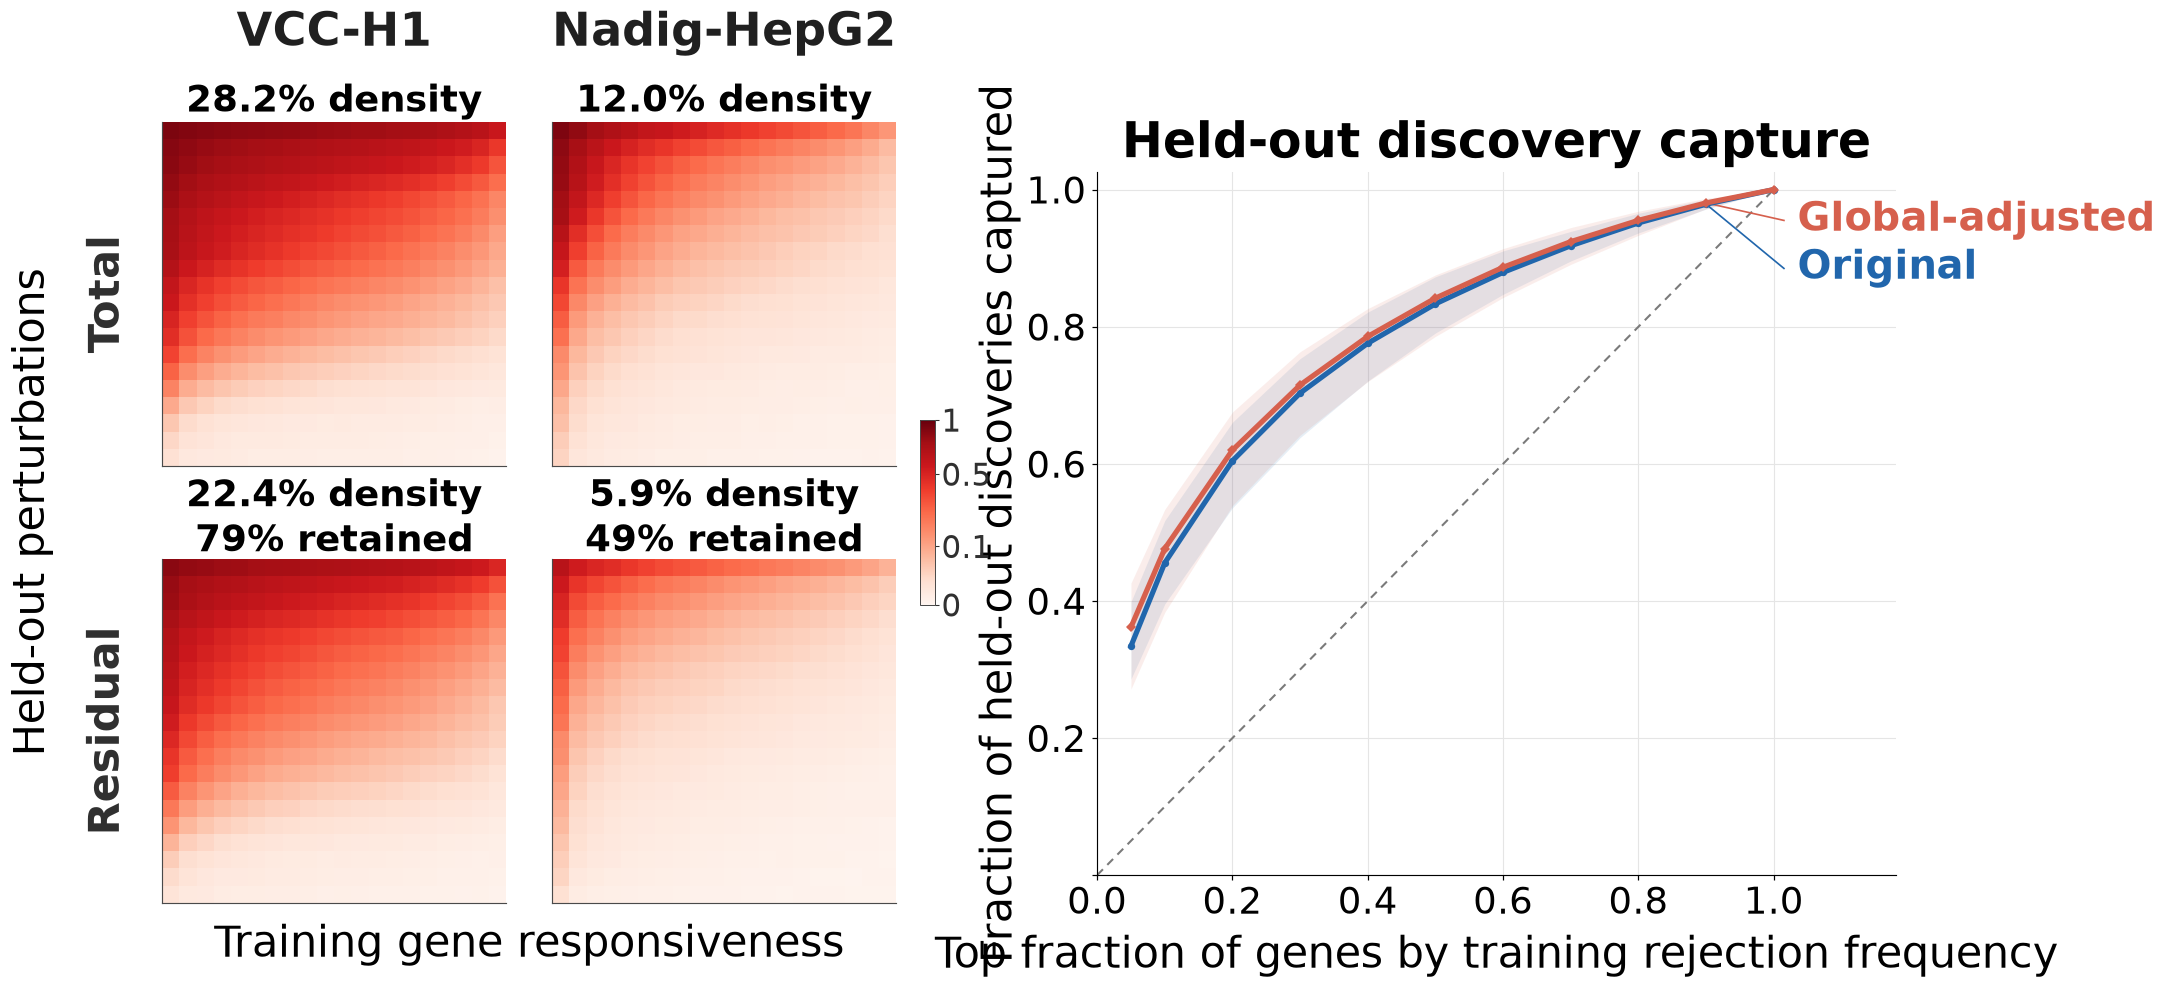

In [2]:
FIG2A_TRIANGLE_DATASETS = ("VCC-H1", "Nadig-HepG2")
FIG2A_ORIGINAL_COLOR = "#2166AC"
FIG2A_ADJUSTED_COLOR = "#D6604D"

triangle = pd.read_csv(TRIANGLES / "matched_original_adjusted_mean_triangle_all_datasets_20x20.csv")
triangle_summary = pd.read_csv(TRIANGLES / "matched_triangle_dataset_summary.csv")
capture_dataset = pd.read_csv(CAPTURE / "matched_capture_curves_by_dataset.csv")
capture_pooled = pd.read_csv(CAPTURE / "matched_capture_curves_equal_dataset_mean.csv")
for frame in (triangle, triangle_summary, capture_dataset):
    frame["display_dataset"] = frame["display_dataset"].map(paper_name)


def style_triangle_axis(axis, title):
    axis.set_title(title, fontsize=24.0, fontweight="bold", linespacing=1.12, pad=5)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.grid(False)  # gridlines across image pixels would draw white crosses
    axis.spines[:].set_linewidth(0.75)
    axis.spines[:].set_color("#4A4A4A")


def pointwise_band(frame, value_column):
    """Pointwise 10th and 90th percentiles over the datasets."""
    return (
        frame.groupby("top_gene_fraction", sort=True)[value_column]
        .quantile([0.10, 0.90])
        .unstack()
        .rename(columns={0.10: "q10", 0.90: "q90"})
        .reset_index()
    )


# Large source sizes: the panel is placed at 65% of a 183-mm page, where they become about 5-7 pt.
use_style({"font.size": 24.0, "axes.linewidth": 0.75}, open_axes=True)
figure = plt.figure(figsize=(18.4, 8.4), facecolor="white")
outer_grid = figure.add_gridspec(
    nrows=1, ncols=2, width_ratios=(0.90, 1.10), left=0.085, right=0.992, bottom=0.080, top=0.925, wspace=0.175
)
heatmap_grid = outer_grid[0, 0].subgridspec(nrows=2, ncols=2, wspace=0.055, hspace=0.27)
heat_axes = {
    (row, column): figure.add_subplot(heatmap_grid[row, column]) for row in range(2) for column in range(2)
}
capture_axis = figure.add_subplot(outer_grid[0, 1])
# A more compact capture panel; the heatmap block keeps its size.
box = capture_axis.get_position()
capture_axis.set_position([box.x0 + 0.020, box.y0 + 0.030, box.width * 0.86, box.height * 0.90])
norm = PowerNorm(gamma=0.5, vmin=0.0, vmax=1.0)

# Total (original Wilcoxon) above Residual (global-trend adjusted, own ordering).
for column, dataset in enumerate(FIG2A_TRIANGLE_DATASETS):
    summary = triangle_summary.loc[triangle_summary["display_dataset"] == dataset].iloc[0]
    top_axis = heat_axes[(0, column)]
    bottom_axis = heat_axes[(1, column)]
    draw_triangle(top_axis, triangle, dataset, "original_mean_rejection_indicator", norm)
    draw_triangle(bottom_axis, triangle, dataset, "adjusted_mean_rejection_indicator_own_order", norm)
    style_triangle_axis(top_axis, f"{100 * float(summary['mean_original_rejection_density_20x20']):.1f}% density")
    style_triangle_axis(
        bottom_axis,
        f"{100 * float(summary['mean_adjusted_rejection_density_20x20']):.1f}% density\n"
        f"{100 * float(summary['mean_fraction_original_calls_retained_20x20']):.0f}% retained",
    )
    top_axis.text(
        0.5, 1.19, dataset, transform=top_axis.transAxes, ha="center", va="bottom", fontsize=30.0,
        fontweight="bold", color="#202020",
    )

# Short shared colour scale beside the heatmap block.
boxes = [axis.get_position() for axis in heat_axes.values()]
right, bottom, top = max(box.x1 for box in boxes), min(box.y0 for box in boxes), max(box.y1 for box in boxes)
colorbar_axis = figure.add_axes([right + 0.012, 0.5 * (bottom + top - 0.20), 0.007, 0.20])
colorbar_mappable = mpl.cm.ScalarMappable(norm=norm, cmap="Reds")
colorbar_mappable.set_array([])
colorbar = figure.colorbar(
    colorbar_mappable, cax=colorbar_axis, orientation="vertical", ticks=[0.0, 0.1, 0.5, 1.0]
)
colorbar.ax.set_yticklabels(["0", "0.1", "0.5", "1"])
colorbar.ax.tick_params(labelsize=20.0, length=2.5, width=0.7, pad=2.0, colors="#303030")
colorbar.outline.set_linewidth(0.65)
colorbar.outline.set_edgecolor("#4A4A4A")

pooled = capture_pooled.sort_values("top_gene_fraction")
original_band = pointwise_band(capture_dataset, "original_fraction_rejections_captured")
adjusted_band = pointwise_band(capture_dataset, "adjusted_fraction_rejections_captured")
for ribbon, color in ((original_band, FIG2A_ORIGINAL_COLOR), (adjusted_band, FIG2A_ADJUSTED_COLOR)):
    capture_axis.fill_between(
        ribbon["top_gene_fraction"].to_numpy(), ribbon["q10"].to_numpy(), ribbon["q90"].to_numpy(),
        color=color, alpha=0.11, linewidth=0, zorder=1,
    )
for value_column, color, marker in (
    ("original_equal_dataset_mean_capture", FIG2A_ORIGINAL_COLOR, "o"),
    ("adjusted_equal_dataset_mean_capture", FIG2A_ADJUSTED_COLOR, "D"),
):
    capture_axis.plot(
        pooled["top_gene_fraction"], pooled[value_column], color=color, linewidth=3.4, marker=marker,
        markersize=4.8, markeredgewidth=0, zorder=4,
    )
capture_axis.plot([0, 1], [0, 1], color="#7A7A7A", linestyle=(0, (4, 3)), linewidth=1.35, zorder=2)
capture_axis.set_xlim(0, 1.18)
capture_axis.set_ylim(0, 1.025)
capture_axis.set_xticks(np.linspace(0, 1, 6))
y_ticks = np.linspace(0, 1, 6)
capture_axis.set_yticks(y_ticks, labels=["" if np.isclose(value, 0.0) else f"{value:.1f}" for value in y_ticks])
capture_axis.set_xlabel("Top fraction of genes by training rejection frequency", fontsize=28.0, labelpad=8)
capture_axis.set_ylabel("Fraction of held-out discoveries captured", fontsize=28.0, labelpad=3)
capture_axis.set_title("Held-out discovery capture", fontsize=32.0, fontweight="bold", pad=10)
capture_axis.tick_params(labelsize=24.0)
capture_axis.grid(True, color="#E5E5E5", linewidth=0.75)
capture_axis.set_axisbelow(True)
capture_axis.spines[["top", "right"]].set_visible(False)

# Curve labels, joined to each curve at the 0.9 fraction.
at_90 = pooled.loc[np.isclose(pooled["top_gene_fraction"], 0.9)].iloc[0]
for value_column, label_y, label, color in (
    ("adjusted_equal_dataset_mean_capture", 0.955, "Global-adjusted", FIG2A_ADJUSTED_COLOR),
    ("original_equal_dataset_mean_capture", 0.885, "Original", FIG2A_ORIGINAL_COLOR),
):
    capture_axis.plot([0.90, 1.015], [float(at_90[value_column]), label_y], color=color, linewidth=1.1, zorder=3)
    capture_axis.text(
        1.035, label_y, label, color=color, fontsize=26.0, fontweight="bold", ha="left", va="center",
        clip_on=False,
    )

# Shared heatmap axis labels and row labels.
figure.canvas.draw()
boxes = [axis.get_position() for axis in heat_axes.values()]
heat_left, heat_right = min(box.x0 for box in boxes), max(box.x1 for box in boxes)
heat_bottom, heat_top = min(box.y0 for box in boxes), max(box.y1 for box in boxes)
figure.text(
    0.5 * (heat_left + heat_right), heat_bottom - 0.046, "Training gene responsiveness", ha="center",
    va="center", fontsize=28.0,
)
figure.text(
    heat_left - 0.064, 0.5 * (heat_bottom + heat_top), "Held-out perturbations", rotation=90,
    rotation_mode="anchor", ha="center", va="center", fontsize=28.0,
)
for row, label in ((0, "Total"), (1, "Residual")):
    positions = [heat_axes[(row, column)].get_position() for column in range(2)]
    row_center = np.mean([0.5 * (position.y0 + position.y1) for position in positions])
    figure.text(
        heat_left - 0.027, row_center, label, rotation=90, rotation_mode="anchor", ha="center", va="center",
        fontsize=28.0, fontweight="bold", color="#303030",
    )

save_panel(figure, FIGURES / "discovery_nestedness_and_capture.pdf", bbox_inches="tight")

# The four drawn triangles, one row per cell (bin 1 = top row / left column).
rows = []
for dataset in FIG2A_TRIANGLE_DATASETS:
    summary = triangle_summary.loc[triangle_summary["display_dataset"] == dataset].iloc[0]
    part = triangle.loc[triangle["display_dataset"] == dataset]
    row_bins = np.sort(part["row_bin"].unique())
    gene_bins = np.sort(part["gene_bin"].unique())
    for effect, value_column, density, retained in (
        ("Total", "original_mean_rejection_indicator",
         float(summary["mean_original_rejection_density_20x20"]), np.nan),
        ("Residual", "adjusted_mean_rejection_indicator_own_order",
         float(summary["mean_adjusted_rejection_density_20x20"]),
         float(summary["mean_fraction_original_calls_retained_20x20"])),
    ):
        matrix = triangle_matrix(triangle, dataset, value_column)
        for row_index, row_bin in enumerate(row_bins):
            for gene_index, gene_bin in enumerate(gene_bins):
                rows.append({
                    "dataset": dataset, "effect": effect,
                    "held_out_perturbation_bin": int(row_bin), "training_gene_bin": int(gene_bin),
                    "mean_rejection_indicator": matrix[row_index, gene_index],
                    "rejection_density": density, "fraction_total_discoveries_retained": retained,
                })
pd.DataFrame(rows).to_csv(DATA / "discovery_nestedness_heatmaps.csv", index=False)

# The two drawn curves and their ribbons.
capture = pooled.loc[
    :, ["top_gene_fraction", "original_equal_dataset_mean_capture", "adjusted_equal_dataset_mean_capture"]
]
for prefix, band in (("original", original_band), ("global_adjusted", adjusted_band)):
    capture = capture.merge(
        band.rename(columns={"q10": f"{prefix}_q10_fraction_captured", "q90": f"{prefix}_q90_fraction_captured"}),
        on="top_gene_fraction",
        how="left",
    )
capture["n_datasets"] = capture["top_gene_fraction"].map(
    capture_dataset.groupby("top_gene_fraction")["display_dataset"].nunique()
)
capture = capture.rename(
    columns={
        "original_equal_dataset_mean_capture": "original_mean_fraction_captured",
        "adjusted_equal_dataset_mean_capture": "global_adjusted_mean_fraction_captured",
    }
)[[
    "top_gene_fraction",
    "original_mean_fraction_captured", "original_q10_fraction_captured", "original_q90_fraction_captured",
    "global_adjusted_mean_fraction_captured", "global_adjusted_q10_fraction_captured",
    "global_adjusted_q90_fraction_captured", "n_datasets",
]]
capture.reset_index(drop=True).to_csv(DATA / "held_out_discovery_capture.csv", index=False)

## Supplementary Fig. S3a — retention of Wilcoxon discoveries under conjunction testing

Percentage of the total-effect Wilcoxon discoveries kept by the total-effect conjunction max(P_Wilcoxon, P for τ = 0) and the residual-effect conjunction max(P_Wilcoxon, P for τ = G) in 10 datasets (Nourreddine-iPSC not shown), from the discovery counts of `RESIDUAL_DISCOVERIES` (`5_response_hierarchy/build_discovery_matrices.py --mode aggregate`).

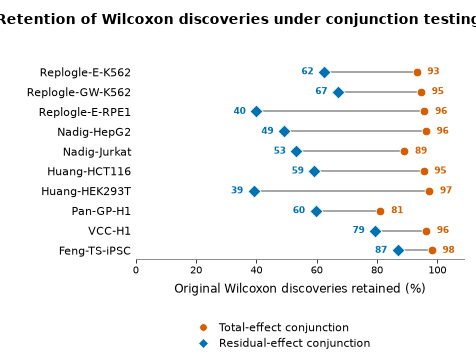

In [3]:
S3A_DISPLAY_ORDER = [name for name in PAPER_ORDER if name not in ("Feng-GW-iPSC", "Nourreddine-iPSC")]
S3A_UNSHIFTED_COLOR = "#D55E00"
S3A_GLOBAL_ADJUSTED_COLOR = "#0072B2"
S3A_RC = {
    "font.size": 7.0, "axes.linewidth": 0.55, "axes.edgecolor": "#666666", "xtick.major.size": 2.3,
    "ytick.major.size": 0.0, "xtick.major.width": 0.50,
}

unshifted_counts = pd.read_csv(RESIDUAL / "unshifted_effect_se_test_rejection_counts_by_dataset.csv")
shifted_counts = pd.read_csv(RESIDUAL / "rejection_count_reduction_by_dataset.csv")
retention = unshifted_counts[
    ["dataset", "n_original_rejections", "display_dataset", "n_unshifted_z_wilcoxon_max_p_rejections"]
].merge(shifted_counts[["dataset", "n_global_trend_adjusted_rejections"]], on="dataset", how="left")
retention["unshifted_conjunction_percent_wilcoxon_kept"] = (
    100 * retention["n_unshifted_z_wilcoxon_max_p_rejections"] / retention["n_original_rejections"]
)
retention["shifted_conjunction_percent_wilcoxon_kept"] = (
    100 * retention["n_global_trend_adjusted_rejections"] / retention["n_original_rejections"]
)
retention["display_dataset"] = retention["display_dataset"].map(paper_name)
display_rank = {dataset: rank for rank, dataset in enumerate(S3A_DISPLAY_ORDER)}
retention = retention.loc[retention["display_dataset"].isin(S3A_DISPLAY_ORDER)].sort_values(
    "display_dataset", key=lambda names: names.map(display_rank)
)

with mpl.rc_context(panel_style(S3A_RC, open_axes=True)):
    figure, axis = plt.subplots(figsize=(110.0 * MM, 84.0 * MM))
    figure.subplots_adjust(left=0.285, right=0.975, top=0.825, bottom=0.285)

    y_positions = np.arange(len(retention))[::-1]
    unshifted = retention["unshifted_conjunction_percent_wilcoxon_kept"].to_numpy()
    adjusted = retention["shifted_conjunction_percent_wilcoxon_kept"].to_numpy()
    for y, left, right in zip(y_positions, adjusted, unshifted):
        axis.plot([left, right], [y, y], color="#9B9B9B", linewidth=1.15, solid_capstyle="round", zorder=1)
    for values, size, marker, color in (
        (unshifted, 32, "o", S3A_UNSHIFTED_COLOR),
        (adjusted, 36, "D", S3A_GLOBAL_ADJUSTED_COLOR),
    ):
        axis.scatter(
            values, y_positions, s=size, marker=marker, color=color, edgecolor="white", linewidth=0.55, zorder=3
        )
    for y, unshifted_value, adjusted_value in zip(y_positions, unshifted, adjusted):
        for value, offset, ha, color in (
            (unshifted_value, 7.0, "left", S3A_UNSHIFTED_COLOR),
            (adjusted_value, -7.0, "right", S3A_GLOBAL_ADJUSTED_COLOR),
        ):
            axis.annotate(
                f"{value:.0f}", (value, y), xytext=(offset, 0), textcoords="offset points", ha=ha, va="center",
                color=color, fontsize=6.2, fontweight="bold", clip_on=False,
            )

    axis.set_yticks(y_positions)
    axis.set_yticklabels(retention["display_dataset"], fontsize=7.3)
    axis.tick_params(axis="y", pad=3.0)
    axis.set_xlim(0, 109.0)
    axis.set_xticks(np.arange(0, 101, 20))
    axis.tick_params(axis="x", labelsize=6.5, pad=2.0)
    axis.set_xlabel("Original Wilcoxon discoveries retained (%)", fontsize=7.7, labelpad=4.5)
    axis.set_ylabel("")
    axis.grid(False)
    axis.spines["left"].set_visible(False)
    axis.spines["bottom"].set_color("#777777")
    figure.suptitle(
        "Retention of Wilcoxon discoveries under conjunction testing", x=0.5, y=0.962, fontsize=9.0,
        fontweight="bold",
    )

    legend_handles = [
        Line2D(
            [], [], linestyle="none", marker=marker, markersize=5.0, markerfacecolor=color,
            markeredgecolor="white", markeredgewidth=0.5, label=label,
        )
        for marker, color, label in (
            ("o", S3A_UNSHIFTED_COLOR, "Total-effect conjunction"),
            ("D", S3A_GLOBAL_ADJUSTED_COLOR, "Residual-effect conjunction"),
        )
    ]
    figure.legend(
        handles=legend_handles, loc="lower center", bbox_to_anchor=(0.59, 0.025), ncol=1, fontsize=7.2,
        handletextpad=0.48, labelspacing=0.36, borderaxespad=0.0,
    )
    save_panel(figure, FIGURES / "conjunction_retention.pdf")

retention.to_csv(DATA / "conjunction_retention.csv", index=False)

## Supplementary Fig. S3b — rejection triangles of eight more datasets

The Fig. 2a triangles (Total above Residual) for eight more datasets: `triangle_visualization_polish/` of `RESIDUAL_DISCOVERIES_CANONICAL`, from `5_response_hierarchy/compute_matched_nestedness.py --mode aggregate`.

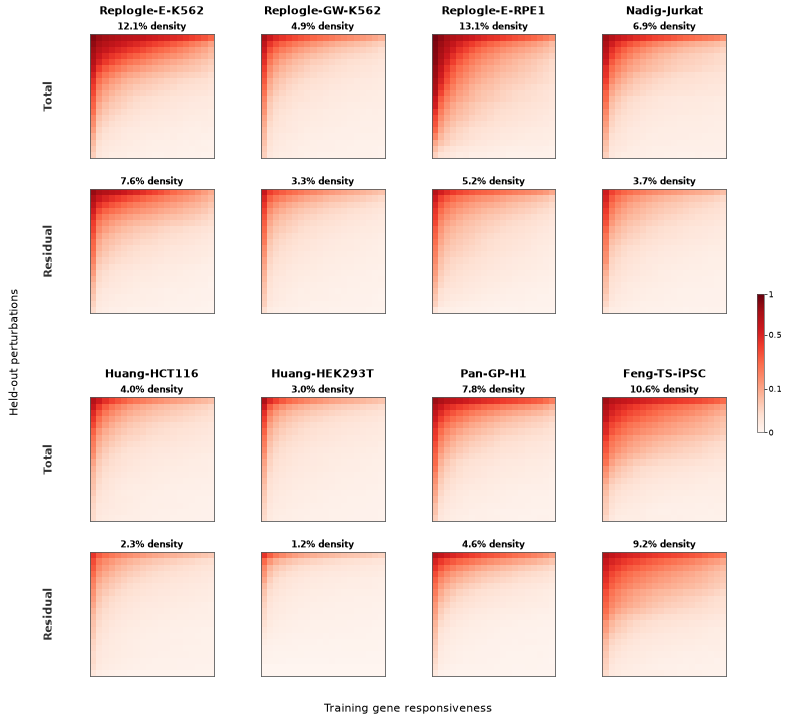

In [4]:
# Two rows of four datasets in the paper order; VCC-H1 and Nadig-HepG2 are in
# Fig. 2a, Nourreddine-iPSC and Feng-GW-iPSC are not shown.
S3B_DATASET_ROWS = (
    ("Replogle-E-K562", "Replogle-GW-K562", "Replogle-E-RPE1", "Nadig-Jurkat"),
    ("Huang-HCT116", "Huang-HEK293T", "Pan-GP-H1", "Feng-TS-iPSC"),
)
S3B_RC = {
    "font.size": 6.0, "axes.linewidth": 0.55, "axes.spines.top": True, "axes.spines.right": True,
    "axes.edgecolor": "#575757", "xtick.major.size": 0.0, "ytick.major.size": 0.0,
}


def style_heatmap_axis(axis, density):
    axis.set_title(f"{100.0 * density:.1f}% density", fontsize=5.7, fontweight="bold", pad=3.2)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.grid(False)
    axis.spines[:].set_linewidth(0.55)
    axis.spines[:].set_color("#595959")


with mpl.rc_context(panel_style(S3B_RC)):
    figure = plt.figure(figsize=(183.0 * MM, 168.0 * MM), facecolor="white")
    # Grid row 2 is the gap between the two dataset bands.
    grid = figure.add_gridspec(
        nrows=5, ncols=4, height_ratios=(1.0, 1.0, 0.18, 1.0, 1.0), left=0.095, right=0.935, bottom=0.070,
        top=0.952, wspace=0.115, hspace=0.30,
    )
    norm = PowerNorm(gamma=0.5, vmin=0.0, vmax=1.0)

    heat_axes = []
    for dataset_band, datasets in enumerate(S3B_DATASET_ROWS):
        total_row = 3 * dataset_band
        for column, dataset in enumerate(datasets):
            summary_row = triangle_summary.loc[triangle_summary["display_dataset"] == dataset].iloc[0]
            total_axis = figure.add_subplot(grid[total_row, column])
            residual_axis = figure.add_subplot(grid[total_row + 1, column])
            image = draw_triangle(total_axis, triangle, dataset, "original_mean_rejection_indicator", norm)
            draw_triangle(residual_axis, triangle, dataset, "adjusted_mean_rejection_indicator_own_order", norm)
            total_axis.text(
                0.5, 1.14, dataset, transform=total_axis.transAxes, ha="center", va="bottom", fontsize=7.4,
                fontweight="bold", clip_on=False,
            )
            style_heatmap_axis(total_axis, float(summary_row["mean_original_rejection_density_20x20"]))
            style_heatmap_axis(residual_axis, float(summary_row["mean_adjusted_rejection_density_20x20"]))
            heat_axes.extend([total_axis, residual_axis])

    figure.text(
        0.018, 0.515, "Held-out perturbations", ha="center", va="center", rotation=90, rotation_mode="anchor",
        fontsize=7.2,
    )
    figure.text(0.515, 0.025, "Training gene responsiveness", ha="center", va="center", fontsize=7.2)

    # Total / Residual labels for each band, from its first dataset's axes.
    for index, label in ((0, "Total"), (1, "Residual"), (8, "Total"), (9, "Residual")):
        position = heat_axes[index].get_position()
        figure.text(
            0.061, position.y0 + position.height / 2, label, ha="center", va="center", rotation=90,
            rotation_mode="anchor", fontsize=7.0, fontweight="bold", color="#303030",
        )

    # One shared scale, as in Fig. 2a.
    colorbar_axis = figure.add_axes([0.955, 0.405, 0.0085, 0.19])
    colorbar = figure.colorbar(image, cax=colorbar_axis)
    colorbar.set_ticks([0.0, 0.1, 0.5, 1.0])
    colorbar.set_ticklabels(["0", "0.1", "0.5", "1"])
    colorbar.ax.tick_params(labelsize=5.5, width=0.45, length=2.0, pad=1.3)
    colorbar.outline.set_linewidth(0.45)
    save_panel(figure, FIGURES / "discovery_nestedness_other_datasets.pdf")